# Assignment


## Task 3: Transfer Learning

In this task, you will apply transfer learning using a pretrained ResNet50 model (use `ResNet50_Weights.IMAGENET1K_V2`) trained on ImageNet.
https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html

Transfer learning is a powerful machine learning technique for leveraging knowledge learned from one task and applying it to a new task. For instance, if a model has been trained to recognize raccoons, the features it has learned (such as shapes, textures, or patterns) can be useful for identifying tanukis, animals with similar visual characteristics. This approach is particularly valuable when the available dataset for the new task is limited in size, making it difficult to train a full-scale model from scratch. The typical workflow for transfer learning in deep learning involves several key steps:

1. **Starting with a pretrained model:** The architecture of a model trained on a large dataset is (partially) replicated, and the weights of some of its layers are imported.
2. **Freezing the pretrained layers:** These layers are frozen (i.e., excluded from the backpropagation update) to prevent the information learned from the initial task from being overwritten during the new training process.
3. **Adding new trainable layers:** These layers are introduced on top of the frozen ones and are specifically designed to adapt the previous knowledge to the new task.
4. **Training on the new dataset:** The model with the new layers is then trained using data from the current task.
5. **Fine-tuning (optional):** In some cases, the entire model (or parts of it) is unfrozen and retrained with a low learning rate. This fine-tuning allows the model to adapt more precisely to the new dataset, often resulting in improved performance.

You will use pretrained features from models trained on a large-scale image recognition dataset, study the effect of transfer learning on model performance and training time, and compare it to the baseline CNN model you trained from scratch in the previous section. You can find an example
of transfer learning here:
https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

Create a new notebook `transferlearning.ipynb`. Again, copy the dataset logic from the first task.

### 1. Set up the classification

- Choose the same metric(s) for this task as you did in the previous one.

### 2. Set up the base model

- Instantiate the model with the ImageNet pretrained weights. Do not include the final fully connected classification layer. _(Note: this is the last layer of the network.)_
- Freeze all layers in the base model.
- Add one or more fully connected layers on top of the base model to fit the classification task.
- Add one dropout layer before the last layer(s). Optionally, add more.
- Print the final architecture.

### 3. Train your model

- For the initial model, start with the best hyperparameters found while optimizing the baseline (when applicable).
- Train your initial model using the previously selected loss function and evaluate the training and validation losses.
- Evaluate the model using the same performance metric(s) chosen in Task 2.
- Ensure that the model runs without errors and that the loss decreases more or less smoothly.
- Plot the training and validation curves.
- Again, tune your hyperparameters in a systematic way, but you do not need to perform a full-scale analysis.

### 4. Train your model on the full dataset

- Retrain your model using the complete training dataset (including the validation dataset), using your previous set of optimal hyperparameters.
- Plot the training curve.
- Save and reload your model.

### 5. Fine-tuning the entire model

- Unfreeze all or part of the base model and train the whole model end-to-end for the same number of epochs as you trained the pretrained model.
- If you notice a sudden drop in performance on the training dataset, reload the model and try again with a smaller learning rate. If there is no sign of improvement, skip this step and use the saved model from the previous step in the following parts. Save the best model.
- Test the saved model on the test dataset and print the performance metric(s) you chose for this problem.
- Display the confusion matrix.
- Plot a few samples from the test dataset (without preprocessing) with their predictions (after preprocessing).

---

In your report, describe the transfer learning you performed, including the following:

- **Model:** How did you choose the architecture for the final layers you added to the pretrained model?
- **Performance:** How did the pretrained model's training curve compare to the final baseline model?
- **Fine-tuning:** Describe any hyperparameters you changed or further fine-tuning you performed.
- **Transfer Learning:** Discuss, based on this experience, the advantages and disadvantages of this approach.


# Solution


Sources

- https://docs.pytorch.org/vision/main/models.html
- https://docs.pytorch.org/vision/main/models.html#using-the-pre-trained-models (resnet50 trained on images with specific transforms!)


Opgekuiste structuur

1. Download and explore
   - describe augmentation (same as for task 2)
2. Custom model 1: ResNet50 + baseline model architecture with same hyperparameters
   - evaluate model performance
   - compare performance to baseline model
3. Custom model 2: same but hyperparameters finetuned
   - finetune hyperparameters
   - evaluate model performance
   - compare to baseline model and to custom model 2
4. Custom model 3: same as previous but ResNet50 weights unfrozen and trained
   - finetune hyperparameters
   - evaluate model performance
   - compare to baseline model, custom model 2 and custom model 3
5. (Optional) Custom model 4: like custom model 1 but reupscaled data instead of original images
   - finetune hyperparameters
   - evaluate performance
   - compare to baseline model


# 0. Setup


Note: Torchvision not in original list of libraries used in the course


In [ ]:
from pathlib import Path
from PIL import Image

import sys

import os

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset

# import torchvision
from torchvision import datasets, models, transforms


from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

import matplotlib.pyplot as plt

Uitbreiden met library time om computationele zwaarte te vergelijken tussen modellen?


In [9]:
# Set the GPU device if present
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

settest_torch_gpu()
device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda
PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda


---


# 1. Introduction


In this section we will start from an existing model whose weights have been pretrained for a different classification task.

The existing model (`ResNet50`) was trained on the ImageNet database of images. Its purpose was to classify images into 1000 distinct classes. The model was introduced in He et al. (2015). Further details and innovations are described [on the `torchvision` website](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html#torchvision.models.resnet50).

After a brief exploration of `ResNet50` we will customize it in different ways, train each customized model and evaluate its performance. This will allow us to assess the effect of different customizations on model performance.

The technique of using an existing model with pretrained weights and adapting it to a different task is known as **transfer learning**.

There are many conceivable ways to add to `ResNet50`, each of which can create a different custom variant model. We chose certain custom variants because they give us the opportunity to answer specific questions about how to improve model performance. Each custom variant is briefly described in the table below.

| Name      | Description                                                                                                          | Purpose                                                                                                                                                                               |
| --------- | -------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `custom1` | pretrained weights + extra layers similar to baseline model from task 2                                              | Is it possible to classify images using features learned in a completely different classification task? How does their performance compare to features learned in the baseline model? |
| `custom2` | Identical to `custom1` but with hyperparameters finetuned through a simple hyperparameter search                     | Does hyperparameter finetuning increase the performance of our customized model?                                                                                                      |
| `custom3` | The architecture is identical to `custom1` and `custom2` but the pretrained weights are opened for further training. | Does further training of the prelearned features increase model performance?                                                                                                          |


---


# 2. The pretrained model


## 2.1 Importing the model


The fully trained `ResNet50` model can be downloaded using the `torchvision` package. We store it in an object `resnet`.


In [10]:
resnet = models.resnet50(weights="IMAGENET1K_V2")

The specific version of the pretrained weights (V2) is determined by the project assignment. This version improves upon the results of He et al. (2015) by implementing a different training recipe. See https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/ for further details.


## 2.2 Exploring the Resnet50 architecture

Resnet50 was designed and trained to classify images of the ImageNet dataset. Therefore, the weights were trained on images with specific characteristics.

The goal of `ResNet50` was to classify images into 1000 output classes.

In this subsection we will explore the architecture of `ResNet50` in order to determine how to modify the data and the model architecture to suit our specific classification task.


#### Inspect architecture, shape of layers


The `state_dict()` method allows us to investigate the different layers and their tensor size. Of particular interest are the first and last layer as they determine what data the model expects and what output the model produces.


In [11]:
keys = list(resnet.state_dict().keys())

print(
    "First layer: ",
    keys[0],
    " has size ",
    resnet.state_dict()[keys[0]].size(),
    "\nLast layer:  ",
    keys[
        -1
    ],  # refers to `fc.bias`, but same conclusion from `fc.weight` (i.e. `keys[-2]`)
    " has size ",
    resnet.state_dict()[keys[-1]].size(),
)

First layer:  conv1.weight  has size  torch.Size([64, 3, 7, 7]) 
Last layer:   fc.bias  has size  torch.Size([1000])


#### The input


Regarding the **first layer**, the elements of this list refer to the out_channels, in_channels, kernel_height and kernel_width respectively.

The number of channels is a hard constraint. In the data exploration phase (task 1), we noticed that the images have 1 channel, while the `ResNet50` model requires three channels (cfr. the RGB mode).

The image size in pixels is not a hard constraint. A forward pass (for training, testing or inference purposes) of images of different sizes will work without error. However, the imported weights were pretrained on images of size 224x224. Generally, we want to assess model performance when the model is used as intended, so we will pass images of size 224x224 to our models.

To do this, we could simply use the original images provided for this assignment. Alternatively, we could (re-)upscale the images of size 128x128 that we produced for our baseline model in task 2. Both options can be valid but the choice has important implications for comparing model performance to the baseline model. Using the original images aligns with our intention of comparing models _that are used as intended_. Reupscaling the 128x128 data to 224x224 would allow us to compare the performance _when both models are fed the same amount of information_.

Finally, the ImageNet data was transformed in specific ways when training the weights in `ResNet50`. These transformations can be accessed and stored for further use. We store them in `preprocess_resnet` so our data can be transformed in the same way, should we choose to do so. See [this page](https://docs.pytorch.org/vision/main/models.html#using-the-pre-trained-models) for details.


In [12]:
weights = models.ResNet50_Weights.IMAGENET1K_V2
preprocess_resnet = weights.transforms()
preprocess_resnet

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

One of the transformations consists of normalizing the data, i.e. subtracting the mean and dividing by the standard deviation. The normalization in `preprocess_resnet` uses the means and standard deviations of the original data that was used to train `ResNet50`. Our data is from a very different domain. This implies that normalization of our data using the descriptive statistics from a different dataset will not yield truly normalized data.


In [ ]:
from pipeline_helper import (
    MyTransform,
    MyPreprocess,
    MyToTensor,
    g_train_mean,
    g_train_std,
)

DATA_DIR = "../../data/1_source/"

# Training-set statistics pre-computed in preprocessing notebook
print(f"Train mean: {g_train_mean:.4f}, std: {g_train_std:.4f}")

Train mean: 0.6063, std: 0.1950


In [ ]:
# g_train_mean = torch.Tensor.item(g_train_mean)
# g_train_std = torch.Tensor.item(g_train_std)

The computed mean and standard deviation refer to the pixel values scaled to the interval $[0,1]$.

Note that our data consists of only one channel. Therefore, we have one mean and one standard deviation. For images in RGB mode, there are 3 channels, each with their own mean and standard deviation. The first layer of `ResNet50` expects 3 channels. We triplicate our 1-channel data (cfr. infra) and the normalization must be applied to each of the three copies/channels.


In [15]:
# preprocess_custom = transforms.Compose(
#     [
#         transforms.Grayscale(num_output_channels=3),
#         transforms.Resize(
#             size=(232, 232),
#             interpolation=transforms.InterpolationMode.BILINEAR,
#         ),
#         transforms.CenterCrop(224),
#         transforms.ToTensor(),
#         transforms.Normalize(
#             mean=[g_train_mean] * 3, std=[g_train_std] * 3
#         ),  # expand to list of 3, one for each channel
#     ]
# )

In conclusion, we will

- use the original data (i.e. images of size 224x224)
- copy the single channel to 3 identical channels
- apply the standard transformations also used by ResNet50 (OR USE MEAN AND STD OF OUR DATA?)
- augment the data in the same way as the data used for training the baseline model.


#### The output


Regarding the **last layer**, we find that the number of output channels is 1000. This corresponds to the original classification task, where the goal was to classify the ImageNet images into 1000 distinct classes. Specifically, the output of the final layer consists of 1000 logits, which can be turned into probabilities and finally into a classification decision.

In contrast, we want our model to classify images into 2 classes: healthy or osteoarthritis (OA). The final layer should be adapted to suit this classification task.


Vervolgens augmentation


---


# 3. Setup for training and evaluation


This section introduces some conveniences for the training process, visualization and evaluation.


In [16]:
# for test runs of code using limited computing power. Change to 30 for final run
epochs = 200

In [17]:
DATA_DIR = "../../data/1_source/"

In [ ]:
import pandas as pd

images_df = pd.read_csv(DATA_DIR + "/images_info.csv")
print(images_df.head())

   split  label      filename       id side   folder img_format    img_size  \
0  train      0  9001695L.png  9001695    L  train/0        PNG  (224, 224)   
1  train      0  9001897L.png  9001897    L  train/0        PNG  (224, 224)   
2  train      0  9003126L.png  9003126    L  train/0        PNG  (224, 224)   
3  train      0  9003126R.png  9003126    R  train/0        PNG  (224, 224)   
4  train      0  9003430L.png  9003430    L  train/0        PNG  (224, 224)   

  img_mode img_info  foreign_objects  pixel_mean  pixel_std  pixel_min  \
0        L       {}                0  138.611547  48.266204       35.0   
1        L       {}                0  180.711755  47.287606        9.0   
2        L       {}                0  216.892917  34.010510       74.0   
3        L       {}                0  189.924107  47.425276       21.0   
4        L       {}                0  141.211336  24.971978       67.0   

   pixel_max  dynamic_range   pixel_sum  pixel_sq_sum  pixel_count  \
0      229

In [19]:
train_dataset_orig = datasets.ImageFolder(os.path.join(DATA_DIR, "train"))

train_orig_loader = DataLoader(train_dataset_orig, batch_size=32, shuffle=True)

In [20]:
# Count the number of samples per class in the training set
class_counts = np.bincount([label for _, label in train_dataset_orig])
print(f"Healthy: {class_counts[0]}, OA: {class_counts[1]}")

# positive weight to make sure the loss function treats the classes equally (one OA mistake is as bad as 2 healthy mistakes)
# If there are 3x more healthy than OA images, pos_weight = 3.0
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(
    device
)
print(f"pos_weight: {pos_weight.item():.2f}")

Healthy: 500, OA: 250
pos_weight: 2.00


Before feeding our data to the model we perform several transformations. Some transformations are augmentations. They are applied randomly and they have the effect of artificially expanding the dataset.

Other transformations are performed to align our data more closely with the original training data, i.e. the ImageNet dataset. These transformations bring the distribution of the data that is put into our model closer to the distribution of the data used for the original training of `ResNet50`.


We distinguish between a set of transformations that should be applied to the training data


In [21]:
# MyTransform and MyPreprocess are imported from pipeline_helper above.
# Use: MyTransform(channels=3, size=(232, 232), centercrop=224)
#      MyPreprocess(channels=3, size=(232, 232), centercrop=224)

Transformations for validation and test data

Note: is using g_train_mean and g_train_std not a form of data leakage? -> ask


In [22]:
# MyPreprocess_tf replaced by MyPreprocess(channels=3, size=(232, 232), centercrop=224)

Generate datasets & dataloaders


In [ ]:
train_dataset = datasets.ImageFolder(
    DATA_DIR + "train",
    transform=MyTransform(channels=3, size=(232, 232), centercrop=224),
)
val_dataset = datasets.ImageFolder(
    DATA_DIR + "val",
    transform=MyPreprocess(channels=3, size=(232, 232), centercrop=224),
)
test_dataset = datasets.ImageFolder(
    DATA_DIR + "test",
    transform=MyPreprocess(channels=3, size=(232, 232), centercrop=224),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train : {len(train_dataset)}")
print(f"Val   : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")

Train : 750
Val   : 159
Test  : 146


Print descriptive statistics of the three splits


In [24]:
print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")
print(f"Classes       : {train_dataset.classes}")

# Sanity check: one batch shape and pixel range after normalization
imgs, labels = next(iter(train_loader))
print(f"Batch shape   : {imgs.shape}  (B, C, H, W)")
print(f"Pixel range   : [{imgs.min():.3f}, {imgs.max():.3f}]")

Train samples : 750
Val samples   : 159
Test samples  : 146
Classes       : ['0', '1']
Batch shape   : torch.Size([32, 3, 224, 224])  (B, C, H, W)
Pixel range   : [-3.109, 2.019]


Model training for hyperparameter search


In [25]:
def train_model(
    model, train_loader, val_loader, criteria, optimizer, num_epochs, device
):
    """Train the model and track metrics per epoch."""
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for epoch in range(num_epochs):
        # Training phase
        model.train()  # Enables dropout and batch norm in training mode
        running_loss = 0.0
        all_preds = []
        all_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)  # BCE expects float labels

            optimizer.zero_grad()  # Reset gradients from previous step
            outputs = model(images).squeeze(1)  # Forward pass, shape: (batch,)
            loss = criteria(outputs, labels)  # Compute loss
            loss.backward()  # Compute gradients
            optimizer.step()  # Update weights

            running_loss += loss.item() * images.size(0)
            # Apply sigmoid to get probabilities, then threshold at 0.5
            preds = (torch.sigmoid(outputs) >= 0.5).int()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_labels, all_preds)

        # Valdation phase
        model.eval()  # Disables dropout, batch norm uses running stats
        running_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():  # No gradient computation needed for validation
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                outputs = model(images).squeeze(1)
                loss = criteria(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).int()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_loss / len(val_loader.dataset)
        val_f1 = f1_score(all_labels, all_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if (epoch + 1) % 5 == 0:  # Print every 5 epochs to reduce clutter
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f} | "
                f"Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}"
            )

    return history

Plot training history


In [26]:
def plot_history(history=None, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves")
    axes[0].legend()

    axes[1].plot(history["train_f1"], label="Train")
    axes[1].plot(history["val_f1"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("F1 Score Curves")
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

---


# 4. Training the customized variants


For each customized variant, we simply copy the pretrained model object (`resnet`) and adapt as needed.


## 4.1 Custom model 1


pretrained weights + extra layers similar to baseline model from task 2


### Data preparation


In [27]:
DATA_DIR = "../../data/1_source/"

In this variant, we copy the hyperparameters from the baseline model from task 2 and therefore, there is no need to perform a hyperparameter search. The training data and the validation data can immediately be pooled into the final full training dataset.


In [28]:
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

### Model preparation


In [29]:
custom1 = resnet.to(device)

In this section, our goal is to use the pretrained weights of `ResNet50` for our classification task. These weights should be frozen to make sure that they are not updated during the training of the _extra_ layers that we add on top of the pretrained model.


In [30]:
for param in custom1.parameters():
    param.requires_grad = False

In [31]:
# Check how many parameters are frozen and not frozen
frozen = sum(p.numel() for p in custom1.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in custom1.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 0 | Frozen: 25,557,032


Parameters of any layers that are added after this stage are, by default, trainable.


### Training


We replace the final layer of the pretrained model with our own custom block of layers.

The dropout rate is taken from our best performing baseline model from task 2.


In [32]:
dropout_rate = 0.5
custom1.fc = nn.Sequential(
    nn.Linear(2048, 128),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(128, 1),
).to(device)

We double-check that the parameters associated with the new layers are indeed trainable.


In [33]:
frozen = sum(p.numel() for p in custom1.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in custom1.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 262,401 | Frozen: 23,508,032


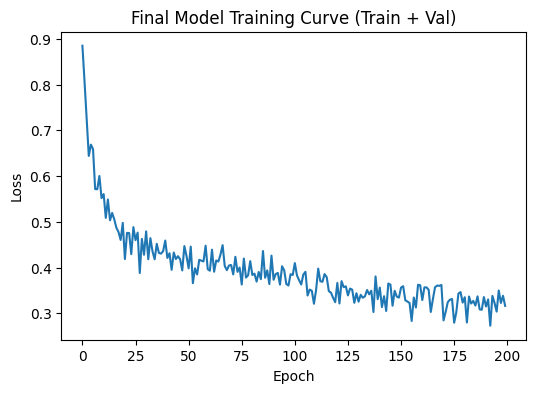

In [34]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(custom1.parameters(), lr=1e-3)

# Train (no validation loader this time — we used all data for training)
custom1.train()
train_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in full_train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = custom1(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader.dataset)
    train_losses.append(epoch_loss)

# Plot final training curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Training Curve (Train + Val)")
plt.show()

### Evaluation


Next we feed the test data to our trained model. The output of each forward pass of a test image is a logit score of belonging to the "positive" class. In this context, that refers to a diagnosis of osteoarthritis.

The logit score can be transformed into a probability using a sigmoid function.

Additionally, we bundle the ground truths of the test data (i.e. the labels).


In [35]:
custom1.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = custom1(images).squeeze(1)
        probs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

If we choose a threshold value and compare it to the predicted probability for each image in the test data, we can end up with a predicted label for each image. For example, we could choose a threshold of `0.50`. If our model predicts a probability of `0.50` or higher for a given image, then that image is predicted to be in class `1`, in other words, that image is predicted to show osteoarthritis.

The threshold is arbitrary. Higher or lower thresholds can be equally valid, depending on our relative tolerance for false negatives versus false positives.

There are different solutions to the issue of arbitrary thresholds.

1. Calculate the Area Under the Curve (AUC), which measures performance across all threshold (i.e. from 0 to 1)
2. Choose a "best" threshold based on a statistical criterion criterion
3. Choose a threshold based on context knowledge


1. AUC


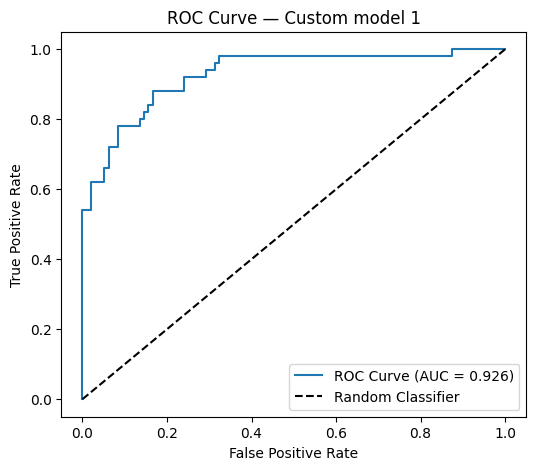

In [36]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Custom model 1")
plt.legend()
plt.show()

2. Youden's J


In [37]:
# Choose threshold (Youden's J statistic)
# This picks the threshold that maximizes (sensitivity + specificity - 1) so false positives and false negatives are equally not there
# this however assumes that false negatives and positives are equally bad
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (Youden's J): {best_threshold:.3f}")
print(
    f"At this threshold: Sensitivity={tpr[best_idx]:.3f}, Specificity={1-fpr[best_idx]:.3f}"
)

Optimal threshold (Youden's J): 0.357
At this threshold: Sensitivity=0.880, Specificity=0.833


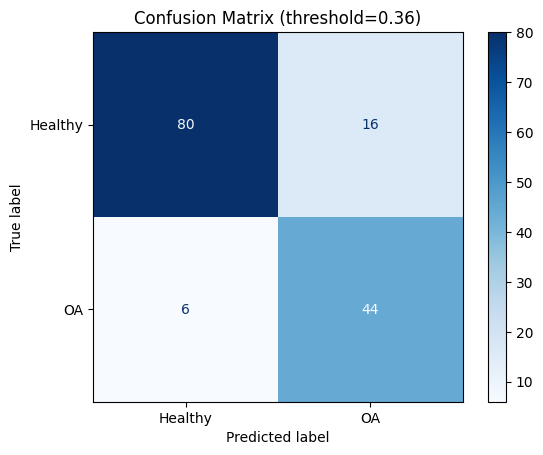

Accuracy: 0.8493
F1 Score: 0.8000


In [38]:
final_preds = (all_probs >= best_threshold).astype(int)
cm = confusion_matrix(all_labels, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
plt.show()

# Print metrics
print(f"Accuracy: {accuracy_score(all_labels, final_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, final_preds):.4f}")

3. Context knowledge: in a medical context, it is conceivable that many patients have a relatively strong aversion to false negatives and a relatively strong tolerance for false positives. In other words, if a patient has osteoarthritis, he or she will want to be diagnosed as such, even at an elevated risk of receiving a positive diagnosis while not having osteoarthritis. We recognize that this is not universally true for all patients (let alone for other involved parties) and for all medical conditions, but we consider it a valuable basis for a thought experiment in this context.


In [39]:
context_threshold = 0.20

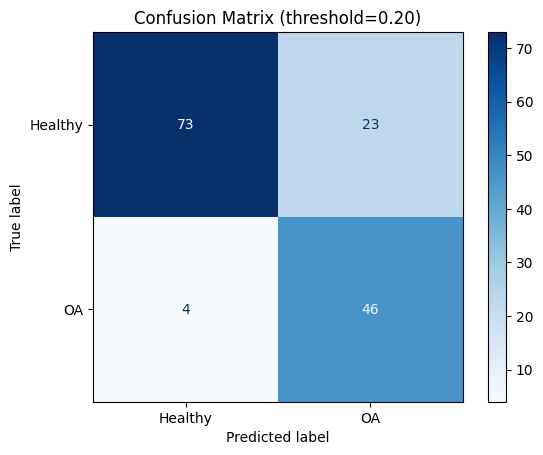

Accuracy: 0.8151
F1 Score: 0.7731


In [40]:
# Confusion Matrix
final_preds = (all_probs >= context_threshold).astype(int)
cm = confusion_matrix(all_labels, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={context_threshold:.2f})")
plt.show()

# Print metrics
print(f"Accuracy: {accuracy_score(all_labels, final_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, final_preds):.4f}")

---


## 4.2 Custom model 2


Identical to `custom1` but with hyperparameters finetuned through a simple hyperparameter search


### Model preparation


In [41]:
custom2 = resnet

In [42]:
for param in custom2.parameters():
    param.requires_grad = False

In [43]:
# Check how many parameters are frozen and not frozen
frozen = sum(p.numel() for p in custom2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in custom2.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 0 | Frozen: 23,770,433


In [44]:
param_configs = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
    {"lr": 1e-4, "dropout": 0.3},
    {"lr": 1e-4, "dropout": 0.5},
]

### Hyperparameter search


In [45]:
best_val_f1 = 0
best_config = None
results = []

for config in param_configs:
    print(f"\nTesting: lr={config['lr']}, dropout={config['dropout']}")

    # IMPORTANT: new model for each run (fresh random weights)

    custom2.fc = nn.Sequential(
        nn.Linear(2048, 128),
        nn.ReLU(),
        nn.Dropout(config["dropout"]),
        nn.Linear(128, 1),
    )

    model = custom2.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=epochs,
        device=device,
    )

    final_val_f1 = history["val_f1"][-1]
    results.append({**config, "val_f1": final_val_f1})

    if final_val_f1 > best_val_f1:
        best_val_f1 = final_val_f1
        best_config = config
        best_history = history

print(f"\nBest config: {best_config} with Val F1: {best_val_f1:.4f}")

# Show all results
for r in results:
    print(f"  lr={r['lr']}, dropout={r['dropout']} → Val F1: {r['val_f1']:.4f}")


Testing: lr=0.001, dropout=0.3
Epoch 5/200 | Train Loss: 0.6641, F1: 0.6806 | Val Loss: 0.7459, F1: 0.7069
Epoch 10/200 | Train Loss: 0.5579, F1: 0.7332 | Val Loss: 0.6379, F1: 0.7656
Epoch 15/200 | Train Loss: 0.4885, F1: 0.7695 | Val Loss: 0.6394, F1: 0.7395
Epoch 20/200 | Train Loss: 0.5426, F1: 0.7435 | Val Loss: 0.7007, F1: 0.7193
Epoch 25/200 | Train Loss: 0.4889, F1: 0.7701 | Val Loss: 0.8176, F1: 0.7170
Epoch 30/200 | Train Loss: 0.4856, F1: 0.7808 | Val Loss: 0.6757, F1: 0.7480
Epoch 35/200 | Train Loss: 0.4793, F1: 0.7802 | Val Loss: 0.6983, F1: 0.7586
Epoch 40/200 | Train Loss: 0.5233, F1: 0.7686 | Val Loss: 0.6036, F1: 0.7194
Epoch 45/200 | Train Loss: 0.4471, F1: 0.8300 | Val Loss: 0.7878, F1: 0.7568
Epoch 50/200 | Train Loss: 0.4096, F1: 0.8129 | Val Loss: 0.8693, F1: 0.7455
Epoch 55/200 | Train Loss: 0.4219, F1: 0.7841 | Val Loss: 0.7136, F1: 0.7244
Epoch 60/200 | Train Loss: 0.3928, F1: 0.8337 | Val Loss: 0.8019, F1: 0.7692
Epoch 65/200 | Train Loss: 0.4281, F1: 0.7903

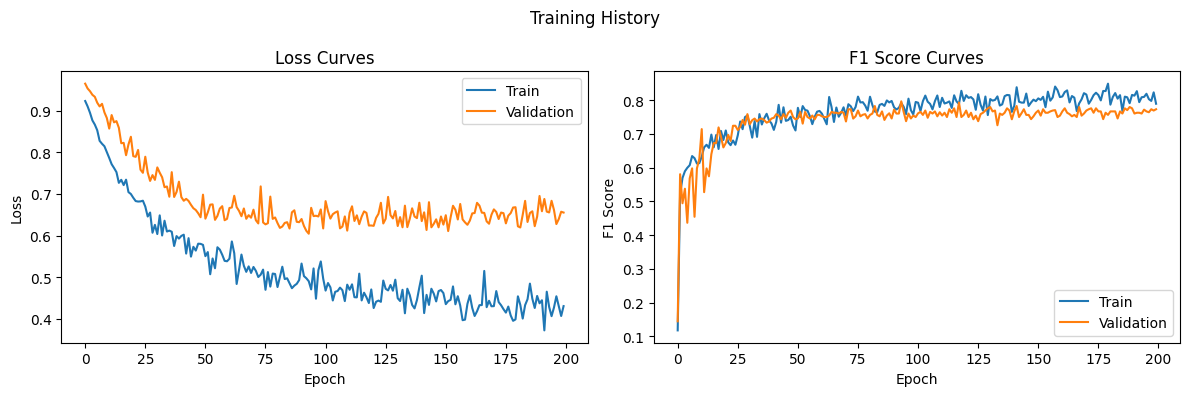

In [46]:
plot_history(
    history
)  # note: is dit de history van de beste config? of gewoon van de laatste?

### Full training


In [47]:
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

### Evaluation


In [48]:
custom2.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = custom2(images).squeeze(1)
        probs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

1. AUC


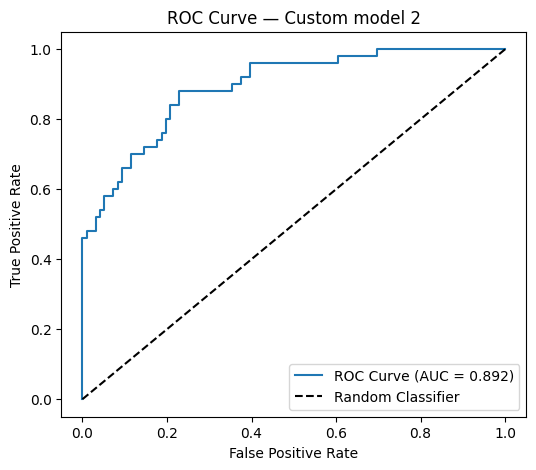

In [49]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Custom model 2")
plt.legend()
plt.show()

2.


In [50]:
# Choose threshold (Youden's J statistic)
# This picks the threshold that maximizes (sensitivity + specificity - 1) so false positives and false negatives are equally not there
# this however assumes that false negatives and positives are equally bad
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (Youden's J): {best_threshold:.3f}")
print(
    f"At this threshold: Sensitivity={tpr[best_idx]:.3f}, Specificity={1-fpr[best_idx]:.3f}"
)

Optimal threshold (Youden's J): 0.386
At this threshold: Sensitivity=0.880, Specificity=0.771


3. Use context knowledge


In [51]:
context_threshold = 0.20

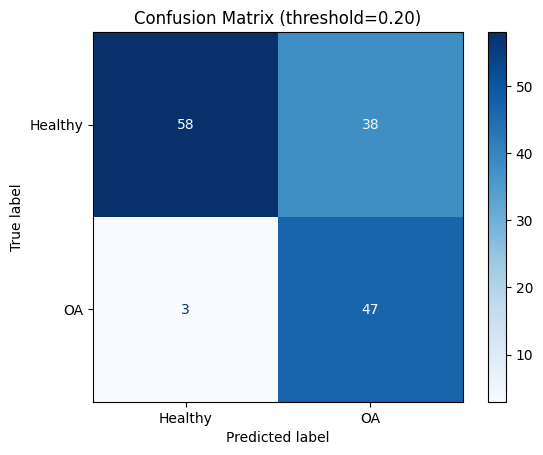

Accuracy: 0.7192
F1 Score: 0.6963


In [52]:
# Confusion Matrix
final_preds = (all_probs >= context_threshold).astype(int)
cm = confusion_matrix(all_labels, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={context_threshold:.2f})")
plt.show()

# Print metrics
print(f"Accuracy: {accuracy_score(all_labels, final_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, final_preds):.4f}")

### Save and reload the model


In [53]:
# overwrite tf_best

In [54]:
# Save and reload
# torch.save(tf_best.state_dict(), "tf_best.pth")
# print("Model saved!")

# # Reload to verify
# loaded_model = BaselineCNN(dropout_rate=best_config["dropout"]).to(device)
# loaded_model.load_state_dict(torch.load("tf_best.pth", map_location=device))
# loaded_model.eval()
# print("Model loaded successfully!")

---


## 4.3 Custom model 3


The architecture is identical to `custom1` and `custom2` but the pretrained weights are opened for further training.


### Data preparation


See earlier: claude convo 22/4


### Model preparation


Unfreeze all or some of the parameters of `ResNet50`


### Hyperparameter search


### Full training


In [55]:
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

### Evaluation


## 4.4 Save best model


In [56]:
# overwrite tf_best if performance is better

In [57]:
# Save and reload
torch.save(tf_best.state_dict(), "tf_best.pth")
print("Model saved!")

# Reload to verify
loaded_model = BaselineCNN(dropout_rate=best_config["dropout"]).to(device)
loaded_model.load_state_dict(torch.load("tf_best.pth", map_location=device))
loaded_model.eval()
print("Model loaded successfully!")

NameError: name 'tf_best' is not defined

---


# 5. Discussion


Compare specific models and discuss the implications.


## 5.1 Custom model 1 versus baseline


Using features learned in a different classification task. We added a very simple block to the `ResNet50`


## 5.2 Custom model 2 versus custom model 1


Does finetuning affect model performance?


## 5.3 Custom model 3 versus custom model 2


What is the effect of retraining the prelearned features on model performance?


---


# OLD


## 3. Add new trainable layers

- https://discuss.pytorch.org/t/add-layers-on-pretrained-model/88760
- https://stackoverflow.com/questions/44406819/pytorch-custom-layer-is-not-a-module-subclass


### Replace final fully connected layer


In [ ]:
# Too many output features (1000)
resnet.fc

ResNet kopie maken voor experimenteren


In [ ]:
resnet_exp = resnet.to(device)

In [ ]:
# Check how many parameters are frozen and not frozen
frozen = sum(p.numel() for p in resnet_exp.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in resnet_exp.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

fc vervangen door 1 nieuwe layer


In [ ]:
# class_names = [0, 1]
num_features = resnet_exp.fc.in_features
resnet_exp.fc = nn.Linear(in_features=num_features, out_features=1)
# Note: output just 1 logit (for the positive class). When using sigmoid function to transform logit to probs, use only one out_feature! (Copilot 16/4)
# Note 2: alternatively, use two out_features, i.e. fc layer outputs two logits (one for each class), but then use softmax to transform logit to probs (Copilot 16/4)

In [ ]:
# Check how many parameters are frozen or not
frozen = sum(p.numel() for p in resnet_exp.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in resnet_exp.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Because the final layer has been added after the freezing of the pretrained weights, it has (by default) `requires_grad = True` and will be trained during backpropagation.


More general method for adding layers


In [ ]:
class CustomBlock(nn.Module):
    def __init__(self, in_features: int, dropout_rate: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

### Add other layers


Uit assignment: "How did you choose the architecture for the final layers you added to the pretrained model?"

- flatten
- conv2d to learn features specific to this dataset
- MaxPool2d
- dropout layer to avoid overfitting (Note: at least one dropout layer before the last layer = required by assignment!)
- batch normalization to stabilize training
- linear
- ReLu for non-linearity
- Softmax?
- Sigmoid?
- One-hot encoding?
- ...

Experimenteren met verschillende combinaties --> welke? waarom? --> zie variant 4


### 3.X

For task 3, we build on the pretrained ResNet50 model. We train several models that differ from the pretrained model in specific ways in order to explore the effect of the modifications. Below, we describe each variant, explaining why it may provide interesting information and/or answers to interesting questions.

In section 4 of this notebook, we train each variant. In section 5 we evaluate the model performance and compare it to other models.


#### Variant 1: ResNet50 + custom block without extra convolutional layers

Gecheckt op 16/4 in github repo:

In task 2, we achieved the best results with the following configuration of hyperparameters:

- Dropout rate: 0.5
- Learning rate: 0.001

Andere hyperparameters om over te nemen?

- Model architecture (number and type of layers)
- Batch size
- Number of epochs
- Weight decay
- Data augmentation choices
- Early stopping


In [ ]:
# Copy resnet to resnet_custom_1
resnet_custom1 = resnet.to(device)

In [ ]:
# Determine dropout rate and learning rate
custom1_hp = {"dropout": 0.5, "lr": 1e-3}

In [ ]:
# define custom block 1
custom1_block = nn.Sequential(  # fc flagged here with message "Sequential is not assignable to Linear", caused by VS Code's static type checker
    nn.Flatten(),
    nn.Linear(64 * 16 * 16, 128),
    nn.ReLU(),
    nn.Dropout(custom1_hp["dropout"]),
    nn.Linear(128, 1),
)

#### Variant 2: ResNet50 + custom block including convolutional layers


In [ ]:
# Determine dropout rate and learning rate
custom2_hp = custom1_hp

We define the custom block for variant 2.

In contrast to variant 1, we now also add the convolutional layers from our baseline model from task 2.

The first convolutional layer in our baseline model accepts only 1 input channel. The last layer of the pretrained model (excluding the final classification) has 2048 output channels. In order to bridge this gap, we adapt the first layer of our custom block. Allowing this layer to accept 2048 input channels would be computationally expensive. Therefore we first use a 1x1 bottleneck convolution to reduce the channel dimension before applying a more expensive spatial convolution.
-> BELANGRIJK: nalezen in He et al. (2015)


In [ ]:
# define custom block 2
custom2_block = nn.Sequential(  # fc flagged here with message "Sequential is not assignable to Linear", caused by VS Code's static type checker
    nn.Conv2d(
        2048, 256, kernel_size=1
    ),  # channel reduction: 2048 → 256 (no spatial mixing)
    nn.ReLU(),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),  # spatial mixing at lower cost
    # Block 1: from 2048 input channels to 16 feature maps with padding to keep size
    nn.Conv2d(in_channels=256, out_channels=16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 128×128 → 64×64
    # Block 2: from 16 to 32 feature maps
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 64×64 → 32×32
    # Block 3: 32 → 64 feature maps
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 32×32 → 16×16
    custom1_block,
)

Comparing the performance of custom variants 1 and 2 will give some indication of the importance of the added convolutional layers. If they


#### Variant 3: hyperparameters finetuned

For our baseline model from task 2, we performed a simple hyperparameter search to discover a configuration of hyperparameters that is finetuned to the task and the model.

In variants 1 and 2 of task 3, that configuration of hyperparameters was simply copied, rather than finetuned.

Now, for variant 3, we will again perform a simple hyperparameter search in order to finetune the hyperparameters.

Comparing the performance of variant 3 to variant 2 will allow us to assess the importance of finetuning.

Comparing this model to our baseline model from task 2 will indicate the added benefit of the pretrained weights. We could have compared either variant 1 or 2 to the baseline model, but we believe our choice gives the most informative comparison: variant 3 conserves both ResNet50 and our baseline model as much as possible, but the hyperparameter finetuning means that its performance is not unnecessarily or artificially held back.


#### Variant 4: pretrained weights unfrozen + custom block with convolution layers (variant 2)

In all variants so far, the weights from ResNet50 were frozen, meaning they were not updated during model training. Only the weights in the additional layers were adapted.

In the current variant, we unfreeze those parameters, allowing them to be adjusted during training.

We perform a new simple hyperparameter search before moving on to the training stage.


In [ ]:
# Unfreeze all parameters
for param in resnet.parameters():
    param.requires_grad = True

In [ ]:
# Perform simple hyperparameter search
param_configs = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
    {"lr": 1e-4, "dropout": 0.3},
    {"lr": 1e-4, "dropout": 0.5},
]

best_val_f1 = 0
best_config = None
results = []

for config in param_configs:
    print(f"\nTesting: lr={config['lr']}, dropout={config['dropout']}")

    # IMPORTANT: new model for each run (fresh random weights)
    model = resnet.to(device)
    dropout_rate = config["dropout"]
    model.fc = nn.Sequential(  # fc flagged here with message "Sequential is not assignable to Linear", caused by VS Code's static type checker
        nn.Linear(2048, 128),
        nn.ReLU(),
        nn.Dropout(custom1_hp["dropout"]),
        nn.Linear(128, 1),
    )

    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=30,
        device=device,
    )

    final_val_f1 = history["val_f1"][-1]
    results.append({**config, "val_f1": final_val_f1})

    if final_val_f1 > best_val_f1:
        best_val_f1 = final_val_f1
        best_config = config
        best_history = history

print(f"\nBest config: {best_config} with Val F1: {best_val_f1:.4f}")

# Show all results
for r in results:
    print(f"  lr={r['lr']}, dropout={r['dropout']} → Val F1: {r['val_f1']:.4f}")

#### Variant 5: experiment with different custom blocks (optional)

Try different number and types of layers

- more conv layers? less? cfr. "how many extra layers needed to learn features for this task?"
- ...

Finetune hyperparameters for each model

Note: choose between frozen and unfrozen pretrained weights based on comparison of variants 2 and 3


#### Variant 6: re-upscaled data (optional)

Previous variants used the original 224x224 images. Baseline model used downscaled images (128x128).

Now feed images with the same information content to (best subvariant of) variant 4

First generate required dataset.

Finetune hyperparameters.

Note: careful when comparing this model to baseline, what question does this comparison answer exactly?


## 4. Train on the new dataset


### 4.1 Setup


In [ ]:
# Set the data directory
DATA_DIR = "../../data/1_source/"  # later: augmented 224x224 data

Adapt the dataset to ResNet50:

- 1 → 3 channels
- 224x224
- Normalize

Note: choice between re-upsampling or using original 224x224 images. See Copilot 15/4. Short version: they answer different questions!

- re-upscaling not necessary! Transfer learning can be done on original 224x224 images. The comparison between the baseline model and the (expanded) ResNet50 should be done based on using both models as they were intended. Architectural differences + resolution differences are both part of "how good the design of model X is".
- optionally: also try with re-upscaled images


In [ ]:
# image transformations copied from original ResNet50 model
transform = weights.transforms()
transform

In [ ]:
# Define the transformations (identical to previous)
transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# note: adapt normalization to training data?

In [ ]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"), transform=transform
)

val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=transform)

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=transform)

In [ ]:
# kopie Carlo ↓

# Compute statistics from your training set to determine the mean and standard deviation for normalization
# means = []
# stds = []
# for images, _ in train_loader:
#     means.append(images.mean())
#     stds.append(images.std())
# mean = torch.tensor(means).mean()
# std = torch.tensor(stds).mean()
# print(f"Computed mean: {mean:.4f}, std: {std:.4f}")

## is dit zinnig?
## ResNet50 heeft eigen normalisatie van input data, zodat distributie van nieuwe input data lijkt op data waarop ResNet50 oorspronkelijk getraind is.
## Hier nieuwe training obv totaal nieuwe data (met dus nieuwe mean en std) dus best normalisatie in lijn met baseline model
## Dus, is dit zinnig? JA
## Maar wel nog aanpassen aan 3 channels (3 means, 3 stds)

In [ ]:
# Kopie Carlo ↓

# Count the number of samples per class in the training set
class_counts = np.bincount([label for _, label in train_dataset])
print(f"Healthy: {class_counts[0]}, OA: {class_counts[1]}")

# positive weight to make sure the loss function treats the classes equally (one OA mistake is as bad as 2 healthy mistakes)
# If there are 3x more healthy than OA images, pos_weight = 3.0
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(
    device
)
print(f"pos_weight: {pos_weight.item():.2f}")

#### Data


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Training functions


In [ ]:
def train_model(
    model, train_loader, val_loader, criteria, optimizer, num_epochs, device
):
    """Train the model and track metrics per epoch."""
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for epoch in range(num_epochs):
        # Training phase
        model.train()  # Enables dropout and batch norm in training mode
        running_loss = 0.0
        all_preds = []
        all_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)  # BCE expects float labels

            optimizer.zero_grad()  # Reset gradients from previous step
            outputs = model(images).squeeze(1)  # Forward pass, shape: (batch,)
            loss = criteria(outputs, labels)  # Compute loss
            loss.backward()  # Compute gradients
            optimizer.step()  # Update weights

            running_loss += loss.item() * images.size(0)
            # Apply sigmoid to get probabilities, then threshold at 0.5
            preds = (torch.sigmoid(outputs) >= 0.5).int()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_labels, all_preds)

        # Valdation phase
        model.eval()  # Disables dropout, batch norm uses running stats
        running_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():  # No gradient computation needed for validation
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                outputs = model(images).squeeze(1)
                loss = criteria(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).int()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_loss / len(val_loader.dataset)
        val_f1 = f1_score(all_labels, all_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if (epoch + 1) % 5 == 0:  # Print every 5 epochs to reduce clutter
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f} | "
                f"Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}"
            )

    return history

In [ ]:
def plot_history(history=None, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves")
    axes[0].legend()

    axes[1].plot(history["train_f1"], label="Train")
    axes[1].plot(history["val_f1"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("F1 Score Curves")
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

#### Hyperparameter finetuning prep


### 4.2 Training


#### Experimental model


In [ ]:
# Train
model = resnet_exp.to(device)
criteria = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model, train_loader, val_loader, criteria, optimizer, num_epochs=30, device=device
)

In [ ]:
plot_history(history)

Hyperparameter search


In [ ]:
# Simple hyperparameter search
param_configs = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
    {"lr": 1e-4, "dropout": 0.3},
    {"lr": 1e-4, "dropout": 0.5},
]

best_val_f1 = 0
best_config = None
results = []

for config in param_configs:
    print(f"\nTesting: lr={config['lr']}, dropout={config['dropout']}")

    # IMPORTANT: new model for each run (fresh random weights)
    model = resnet.to(device)
    dropout_rate = config["dropout"]
    model.fc = nn.Sequential(  # fc flagged here with message "Sequential is not assignable to Linear", caused by VS Code's static type checker
        nn.Conv2d(
            2048, 256, kernel_size=1
        ),  # channel reduction: 2048 → 256 (no spatial mixing)
        nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),  # spatial mixing at lower cost
        # Block 1: from 2048 input channels to 16 feature maps with padding to keep size
        nn.Conv2d(in_channels=256, out_channels=16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 128×128 → 64×64
        # Block 2: from 16 to 32 feature maps
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 64×64 → 32×32
        # Block 3: 32 → 64 feature maps
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 32×32 → 16×16
        nn.Flatten(),
        nn.Linear(64 * 16 * 16, 128),
        nn.ReLU(),
        nn.Dropout(custom1_hp["dropout"]),
        nn.Linear(128, 1),
    )

    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=30,
        device=device,
    )

    final_val_f1 = history["val_f1"][-1]
    results.append({**config, "val_f1": final_val_f1})

    if final_val_f1 > best_val_f1:
        best_val_f1 = final_val_f1
        best_config = config
        best_history = history

print(f"\nBest config: {best_config} with Val F1: {best_val_f1:.4f}")

# Show all results
for r in results:
    print(f"  lr={r['lr']}, dropout={r['dropout']} → Val F1: {r['val_f1']:.4f}")

In [ ]:
# Combine train and val for final training
# Create new datasets without augmentation for val portion
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

# Fresh model with best hyperparameters
final_model = resnet.to(device)
dropout_rate = config["dropout"]
final_model.fc = nn.Sequential(
    nn.Conv2d(
        2048, 256, kernel_size=1
    ),  # channel reduction: 2048 → 256 (no spatial mixing)
    nn.ReLU(),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),  # spatial mixing at lower cost
    # Block 1: from 2048 input channels to 16 feature maps with padding to keep size
    nn.Conv2d(in_channels=256, out_channels=16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 128×128 → 64×64
    # Block 2: from 16 to 32 feature maps
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 64×64 → 32×32
    # Block 3: 32 → 64 feature maps
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 32×32 → 16×16
    nn.Flatten(),
    nn.Linear(64 * 16 * 16, 128),
    nn.ReLU(),
    nn.Dropout(best_config["dropout"]),
    nn.Linear(128, 1),
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(final_model.parameters(), lr=best_config["lr"])

# Train (no validation loader this time — we used all data for training)
final_model.train()
train_losses = []

for epoch in range(30):
    running_loss = 0.0
    for images, labels in full_train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = final_model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader.dataset)
    train_losses.append(epoch_loss)

# Plot final training curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Training Curve (Train + Val)")
plt.show()

# Save and reload
torch.save(final_model.state_dict(), "baseline_model.pth")
print("Model saved!")

# Reload to verify
loaded_model = BaselineCNN(dropout_rate=best_config["dropout"]).to(device)
loaded_model.load_state_dict(torch.load("baseline_model.pth", map_location=device))
loaded_model.eval()
print("Model loaded successfully!")

#### Variant 1


In [ ]:
# Training the expanded ResNet50 model
resnet_custom_1 = resnet.to(device)
resnet_custom_1.fc = custom_block_1

criteria = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model=resnet_custom_1, train_loader, val_loader, criteria, optimizer,
    num_epochs=30, device=device
)

Plot training history


In [ ]:
plot_history(history)

#### Hyperparameters

From assignment: "start with the best hyperparameters found while optimizing the baseline (when applicable)"


### 4.2 Loss function and optimizer


Define loss function and optimizer

Nu: hoe?
Later: keuzes maken en verantwoorden


Uit assignment: "For the initial model, start with the best hyperparameters found while optimizing the
baseline (when applicable)."

M.a.w. learning rate, loss function etc. overnemen van taak 2


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.adam()

Training loop skeleton


In [ ]:
# AI generated ↓

tf_resnet.train()

for epoch in range(num_epochs):
    for images, labels in dataloader:
        labels = labels.float().unsqueeze(1)  # shape: (batch, 1)
        optimizer.zero_grad()  # clear gradients from previous step
        outputs = tf_resnet(images)  # forward pass → shape: (batch, 1)
        loss = criterion(outputs, labels)
        loss.backward()  # compute gradients
        optimizer.step()  # update weights

### 4.X Hyperparameter search


In [ ]:
# ↓ Kopie van Carlo

# Simple hyperparameter search
param_configs = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
    {"lr": 1e-4, "dropout": 0.3},
    {"lr": 1e-4, "dropout": 0.5},
]

best_val_f1 = 0
best_config = None
results = []

for config in param_configs:
    print(f"\nTesting: lr={config['lr']}, dropout={config['dropout']}")

    # IMPORTANT: new model for each run (fresh random weights)
    model = BaselineCNN(dropout_rate=config["dropout"]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=30,
        device=device,
    )

    final_val_f1 = history["val_f1"][-1]
    results.append({**config, "val_f1": final_val_f1})

    if final_val_f1 > best_val_f1:
        best_val_f1 = final_val_f1
        best_config = config
        best_history = history

print(f"\nBest config: {best_config} with Val F1: {best_val_f1:.4f}")

# Show all results
for r in results:
    print(f"  lr={r['lr']}, dropout={r['dropout']} → Val F1: {r['val_f1']:.4f}")

### 4.X Initial training

See assignment details (p.7-8), among others:

- "plot the training and validation curves"
- "tune your hyperparameters in a systematic way"


### 4.X Full training

See assignment details (p.8)


In [ ]:
# Print architecture and parameter count
model = tf_resnet_exp(dropout_rate=0.5).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

### 4.X Save and reload model


## 5. Finetune (optional)


See assignment details (p.8)

- "Unfreeze all or part of the base model and train the whole model end-to-end for the same number of epochs as you trained the pretrained model."


In [ ]:
for param in tf_resnet.parameters():
    param.requires_grad = True

## 6. Inference


Do not forget:

1. resnet50 expects specific data transformations to be performed on images
2. set to evaluation mode: tf_resnet.eval()


In [ ]:
resnet_exp.eval()

with torch.no_grad():
    outputs = resnet_exp(images)  # raw logits
    probs = torch.sigmoid(outputs)  # convert to probabilities in [0, 1]
    preds = (probs >= 0.5).long()  # threshold at 0.5 → 0 or 1

In [ ]:
print(preds)

Hierboven: AI-generated code

- andere threshold probability gebruiken (cfr. vermijden van false negatives)


## 7. Model evaluation metrics


### 7.1 Test run of original pretrained ResNet50

- fed the new dataset with preprocessing
- with the new final fully connected layer, 2 output classes
- but otherwise unchanged.

(Noot: indien hele slechte performance: classificatie gewoon omkeren?)

Goed nadenken: is dit zinnig? Weights van nieuwe laatste layer zijn willekeurig geinitialiseerd?


In [ ]:
# preprocess images analogously to ResNet50

preprocess = (
    weights.transforms()
)  # object weights stores transforms that were applied to ImageNet data

DATA_DIR = "../../data/1_source"

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=preprocess
)

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Replace final fully connected layer
class_names = [0, 1]
num_features = tf_resnet.fc.in_features
tf_resnet.fc = nn.Linear(in_features=num_features, out_features=1)
# must be 1 output because sigmoid used later on (see Copilot chat 16/4)
# no sigmoid in model itself: BCEWithLogitsLoss includes it internally

In [ ]:
# feed (transformed) random data as check
tf_resnet.eval()  # set model to evaluation mode

with torch.no_grad():  # no updating of gradients
    logit = tf_resnet(random_data_pp)
    prob = torch.sigmoid(logit)
    pred = 1 if prob >= 0.5 else 0  # arbitrary cutoff

In [ ]:
print(torch.Tensor.item(logit[0][0]), "\n", torch.Tensor.item(prob[0][0]), "\n", pred)

In [ ]:
resnet_exp.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = resnet_exp(images).squeeze(1)
        probs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [ ]:
all_preds = np.where(all_probs >= 0.5, 1, 0)

In [ ]:
tp = np.where((all_preds == all_labels) & all_labels == 1, True, False)

In [ ]:
np.sum(tp)

Discuss test run.

Mention differences between the ImageNet dataset/classification task versus this one

- ImageNet: distinguish between scuba diver and an artichoke
- KneeOA: distinguish between knees that may only be subtly different

Therefore, we expect poor performance.


#### Calculate & Visualize metrics


In [ ]:
# ↓ Kopie Carlo

# AUC and ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ResNet50 binary")
plt.legend()
plt.show()

In [ ]:
# ↓ Kopie Carlo

# Choose threshold (Youden's J statistic)
# This picks the threshold that maximizes (sensitivity + specificity - 1) so false positives and false negatives are equally not there
# this however assumes that false negatives and positives are equally bad
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (Youden's J): {best_threshold:.3f}")
print(
    f"At this threshold: Sensitivity={tpr[best_idx]:.3f}, Specificity={1-fpr[best_idx]:.3f}"
)

In [ ]:
# ↓ Kopie Carlo

# Confusion Matrix
final_preds = (all_probs >= best_threshold).astype(int)
cm = confusion_matrix(all_labels, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
plt.show()

# Print metrics
print(f"Accuracy: {accuracy_score(all_labels, final_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, final_preds):.4f}")

In [ ]:
# Confusion Matrix
my_threshold = 0.5
final_preds = (all_probs >= my_threshold).astype(int)
cm = confusion_matrix(all_labels, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={my_threshold:.2f})")
plt.show()

# Print metrics
print(f"Accuracy: {accuracy_score(all_labels, final_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, final_preds):.4f}")

#### Discuss performance


Assessment of performance of ResNet50 out of the box

- Considering that an AUC of 0.50 is to be expected in a binary classifier that guesses randomly, and considering that the model has not learned any new features, the obtained AUC here is already quite impressive.
- He et al. (2015, p.2): "The extremely deep representations [...] have excellent generalization performance on other recognition tasks".
  - Performance in this task demonstrates that He et al. are right.


### 7.2 Expanded ResNet50


#### Calculate & Visualize performance metrics


#### Discuss performance


#### Compare model to baseline model performance

- Yosinski et al. (2014, p.1): "initializing a network with transferred features from almost any number of layers can produce a boost to generalization that lingers even after fine-tuning to the target dataset."


## 8. Inspect predictions


In [ ]:
from img_helper import show_images

display_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyToTensor()
)
CLASS_NAMES = ["Healthy", "OA"]

show_images(
    list(range(10)),
    display_dataset,
    all_labels,
    final_preds,
    all_probs,
    CLASS_NAMES,
    title="Test Predictions (green=correct, red=wrong)",
)

## X. Further research

- Different choices in preprocessing: do they make a difference?
  - Adapt ResNet50 to dataset (1 channel, 128x128) instead of the other way around
  - Other methods of upscaling from 128x128 to 224x224
